In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [46]:
def load_and_calculate_errors(file_path, estimated_col, true_col):
    """Loads data and calculates errors."""
    data = pd.read_csv(file_path, header=0, index_col=0)
    return calc_erros(data[estimated_col], data[true_col])

def gather_statistics(errors, rmse, mae, std):
    """Extracts RMSE, MAE, and STD from error dictionary and appends to lists."""
    rmse.append(errors["RMSE"])
    mae.append(errors["MAE"])
    std.append(errors["STD"])

def prepare_error_dataframe(ols_est, column_extraction ,errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"]),
               pd.DataFrame(np.abs(column_extraction), columns=["Column extraction"])]
    
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)

def plot_errors(err, rmse, mae, std, ax, level):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    sns.boxplot(data=df_long, y="value", hue="variable", ax=ax)
    
    ax.set_title(f"Confounding level {level}", fontsize=20)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=20)
    ax.set_xlabel("Methods", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_ylim((0,8))
    palette = sns.color_palette(n_colors=err.shape[1])
    #handles = [
    #    mpatches.Patch(color=palette[i], label=f"RMSE = {rmse[i]:.2f}, MAE = {mae[i]:.2f}, Std = {std[i]:.2f}  : {err.columns[i]}")
    #    for i in range(len(err.columns))
    #]
    handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    ax.legend(handles=handles, loc="upper center", fontsize=15)

from sklearn.linear_model import LinearRegression
def calculate_ols_estimate(path = "data_generation/different_confounding_levels/data/", name = "data_obs_large_conf_3_"):
    ols_est = []
    for i in range(100):
        data = pd.read_csv(f"../{path}{name}{i}.csv")
        est = LinearRegression()
        # regress last column on all other columns
        est.fit(data.iloc[:, :-1], data.iloc[:, -1])
        ols_est.append(est.coef_[-1])

    return ols_est

def calc_erros(est, true):
    err = est-true
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    std = np.std(err)
    return {"RMSE": rmse, "MAE": mae, "STD": std, "error": np.abs(err)}


def column_extraction(path = "data_generation/different_confounding_levels/data/", name  = "estimated_mixing_CausalVarEM_large_conf_1_"):
    est = []
    for i in range(100):
        data = pd.read_csv(f"../{path}{name}_{i}.csv")
        est.append(data.iloc[-1, -2])
    return est


def get_true_treatment_effect(path, name):
    true = []
    for i in range(100):
        data = pd.read_csv(f"../{path}{name}{i}.csv")
        true.append(data.iloc[-1, -2])
    return true

def print_method_summary(method_summary):
    for level in method_summary.keys():
        print(f"Level {level}")
        col = method_summary[level]["cases"].keys()
        cases = method_summary[level]["cases"].values()

        print(pd.DataFrame([method_summary[level]["rmse"], method_summary[level]["mae"], method_summary[level]["std"], cases], columns=col, index=["RMSE", "MAE", "STD", "Cases"]))


# Plot increase in confounding

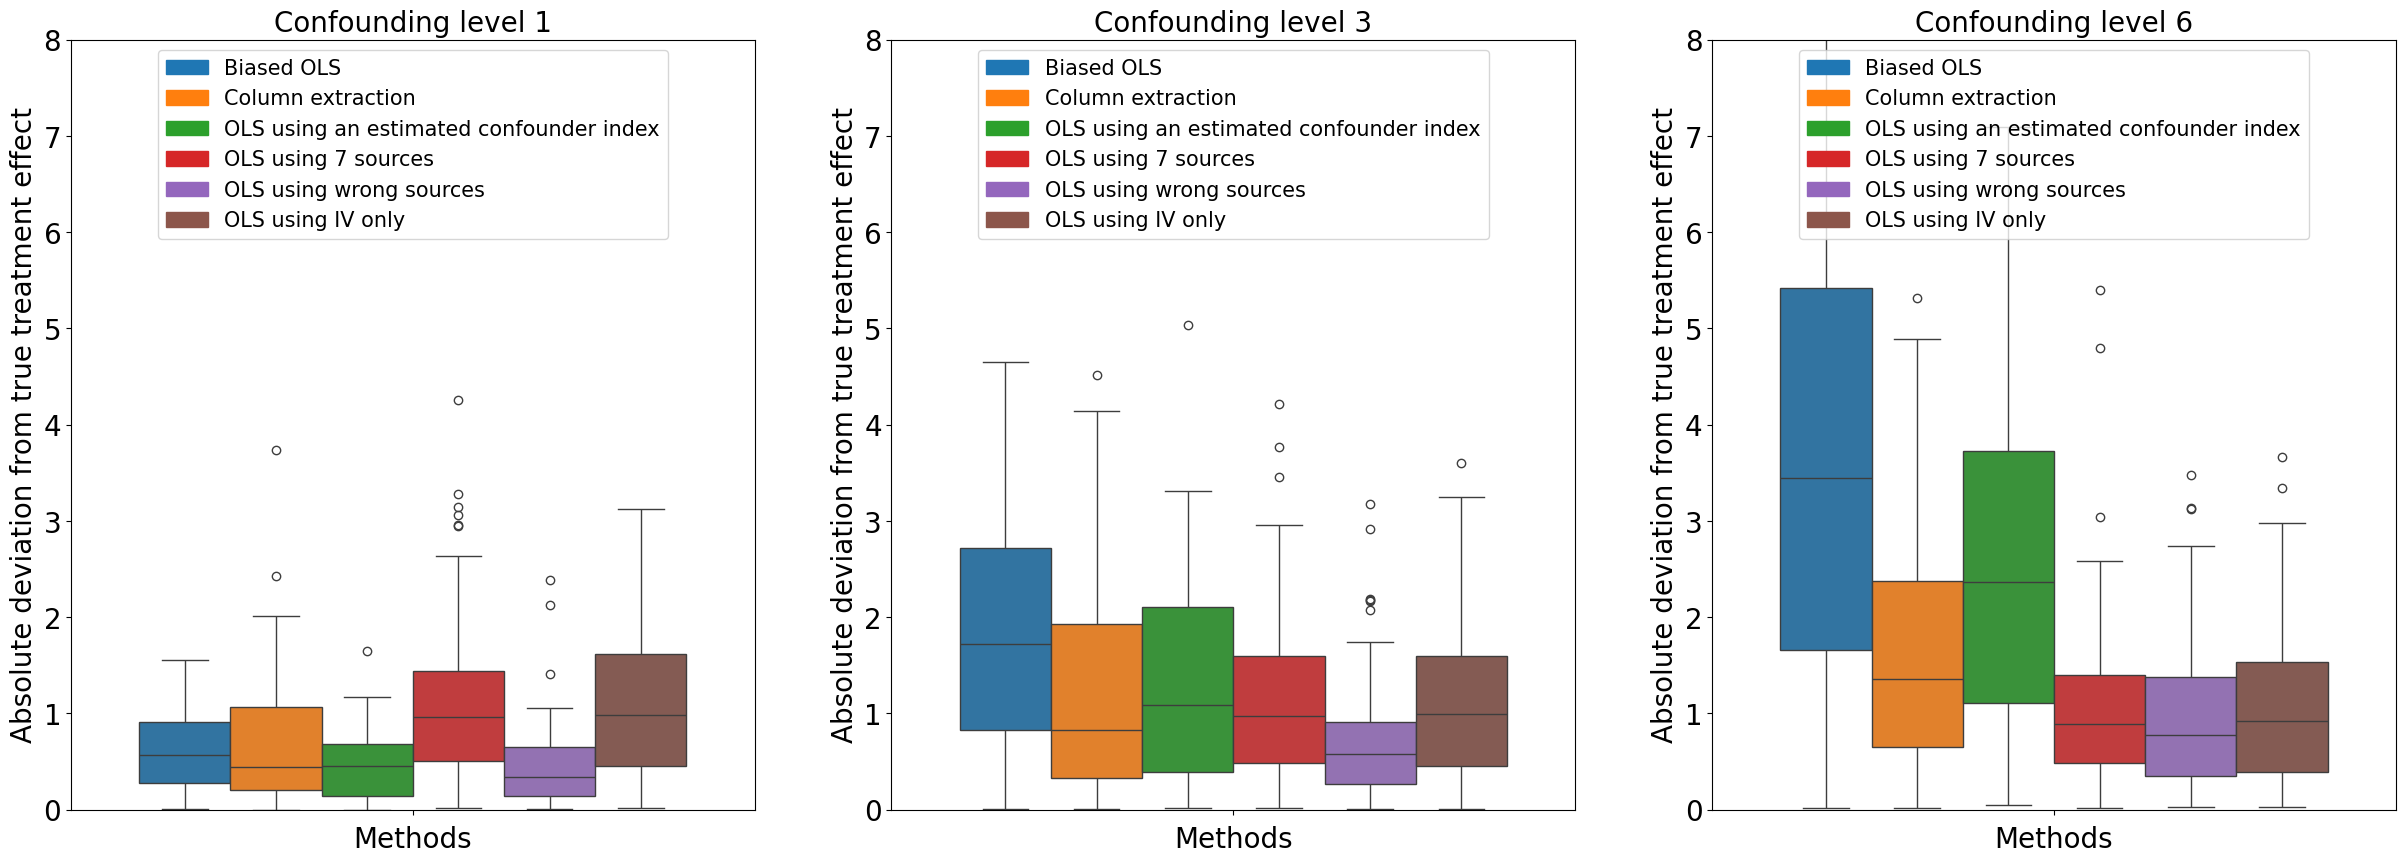

In [40]:

def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(30, 10))
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/different_confounding_levels/data/", name  = f"estimated_mixing_CausalVarEM_large_conf_{level}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], level)
    
    plt.show()
    return method_summary



# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)
# print method summary as a table


In [41]:
print_method_summary(method_summary)

Confounding level 1
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.595175   
MAE      0.585996           0.674720                                 0.473394   
STD      0.687864           0.921088                                 0.590949   
Cases  100.000000         100.000000                                76.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.376951                 0.613627           1.349548  
MAE               1.101847                 0.447374           1.106903  
STD               1.357780                 0.609622           1.345847  
Cases            95.000000                84.000000          86.000000  
Confounding level 3
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     2.060265           1.578265                                 1.708286   
MAE      1.753669          

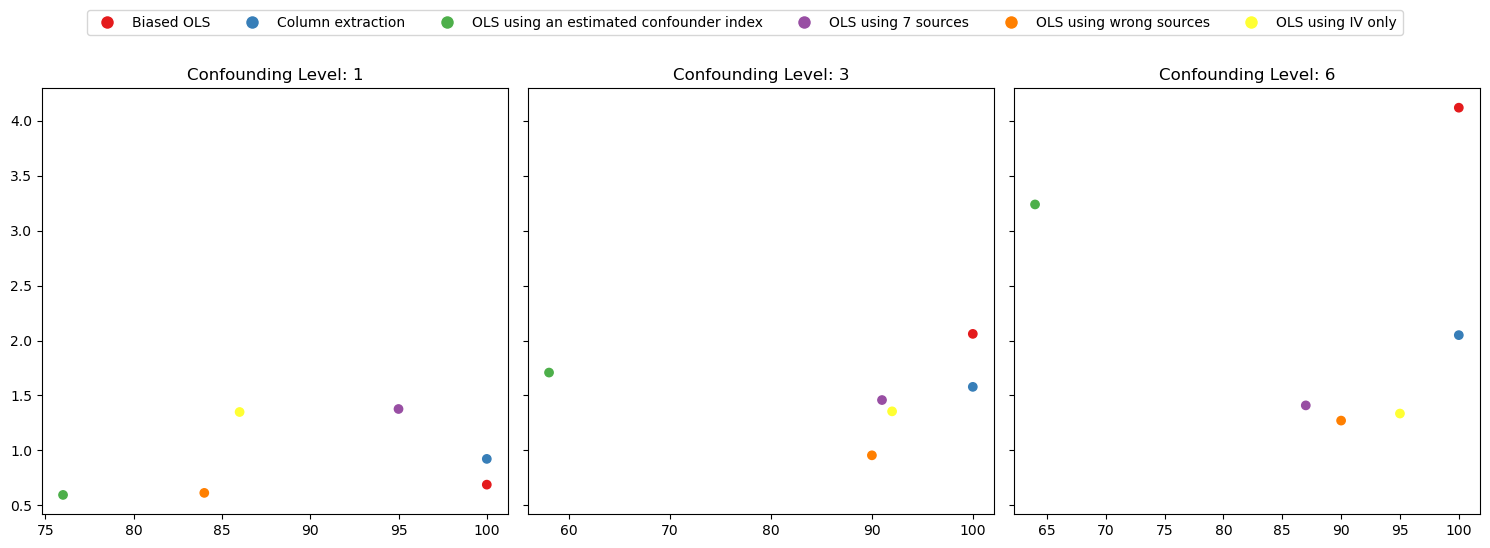

In [42]:
def new_func():
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Define the color palette
    palette = sns.color_palette("Set1", 6)

# Iterate over the confounding levels and plot the data
    for i, level in enumerate(confounder_levels):
        methods = method_summary[level]["cases"].keys()
        cases = method_summary[level]["cases"].values()
        rmse = method_summary[level]["rmse"]
        
    # Scatter plot
        ax[i].scatter(cases, rmse, c=palette, label=methods)
    
    # Set the title with confounding level
        ax[i].set_title(f"Confounding Level: {level}")

# Create the legend handles
    legend_labels = list(methods)
    legend_colors = palette[:len(legend_labels)]
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add the legend above all subplots
    fig.legend(handles, legend_labels, loc='upper center', ncol=len(legend_labels), bbox_to_anchor=(0.5, 1.1))
    plt.tight_layout()
# Show the plot
    plt.show()

new_func()

# Plot bounded treatment

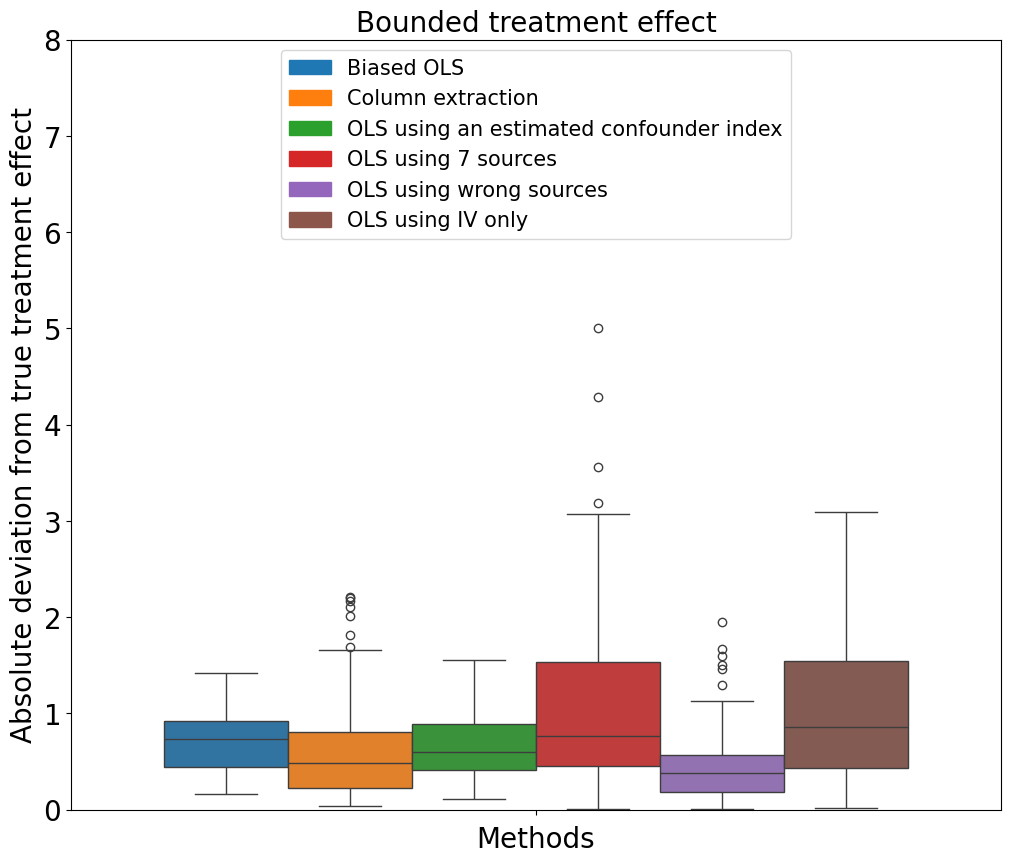

Bounded treatment effect
                                             RMSE       MAE       STD
Biased OLS                               0.779054  0.713521  0.777512
Column extraction                        0.837573  0.633105  0.834212
OLS using an estimated confounder index  0.718761  0.643209  0.711011
OLS using 7 sources                      1.405930  1.068531  1.397806
OLS using wrong sources                  0.624218  0.466707  0.621061
OLS using IV only                        1.284055  1.032078  1.262986


In [43]:
def plot_errors_bounded(err, rmse, mae, std,ax):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    sns.boxplot(data=df_long, y="value", hue="variable", ax=ax)
    
    ax.set_title(f"Bounded treatment effect", fontsize=20)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=20)
    ax.set_xlabel("Methods", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_ylim((0,8))
    palette = sns.color_palette(n_colors=err.shape[1])
    #handles = [
    #    mpatches.Patch(color=palette[i], label=f"RMSE = {rmse[i]:.2f}, MAE = {mae[i]:.2f}, Std = {std[i]:.2f}  : {err.columns[i]}")
    #    for i in range(len(err.columns))
    #]
    handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    ax.legend(handles=handles, loc="upper center", fontsize=15)
true_treatment = get_true_treatment_effect(path="data_generation/bounded_treatment_effect/data/", name="true_mixing_init_flipp_")
ols_est = calculate_ols_estimate(path=f"data_generation/bounded_treatment_effect/data/", name= "data_obs_init_flipp_")
ols_est = np.array(ols_est) - np.array(true_treatment)

column_extraction_est = column_extraction(path = "data_generation/bounded_treatment_effect/data/", name  = "estimated_mixing_CausalVarEM_init_flipp")
column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment)



errors_confounder = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_bounded_treatment.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_7_sources = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_bounded_treatment.csv", "estimated_treatment_on_sources", "true_treatment_effect")
errors_nonsense = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_bounded_treatment.csv", "mistaken_scheme", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_bounded.csv", "iv_only_effect", "true_treatment_effect")

rmse, mae, std = [], [], []
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)
gather_statistics(errors_confounder, rmse, mae, std)
gather_statistics(errors_7_sources, rmse, mae, std)
gather_statistics(errors_nonsense, rmse, mae, std)
gather_statistics(errors_iv_only, rmse, mae, std)

err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plot_errors_bounded(err, rmse, mae, std, ax)  # Use ax instead of ax[0]
plt.show()

# print metric summary
print("Bounded treatment effect")
print(pd.DataFrame({"RMSE": rmse, "MAE": mae, "STD": std}, index=err.columns))

## Plot different number of covariates

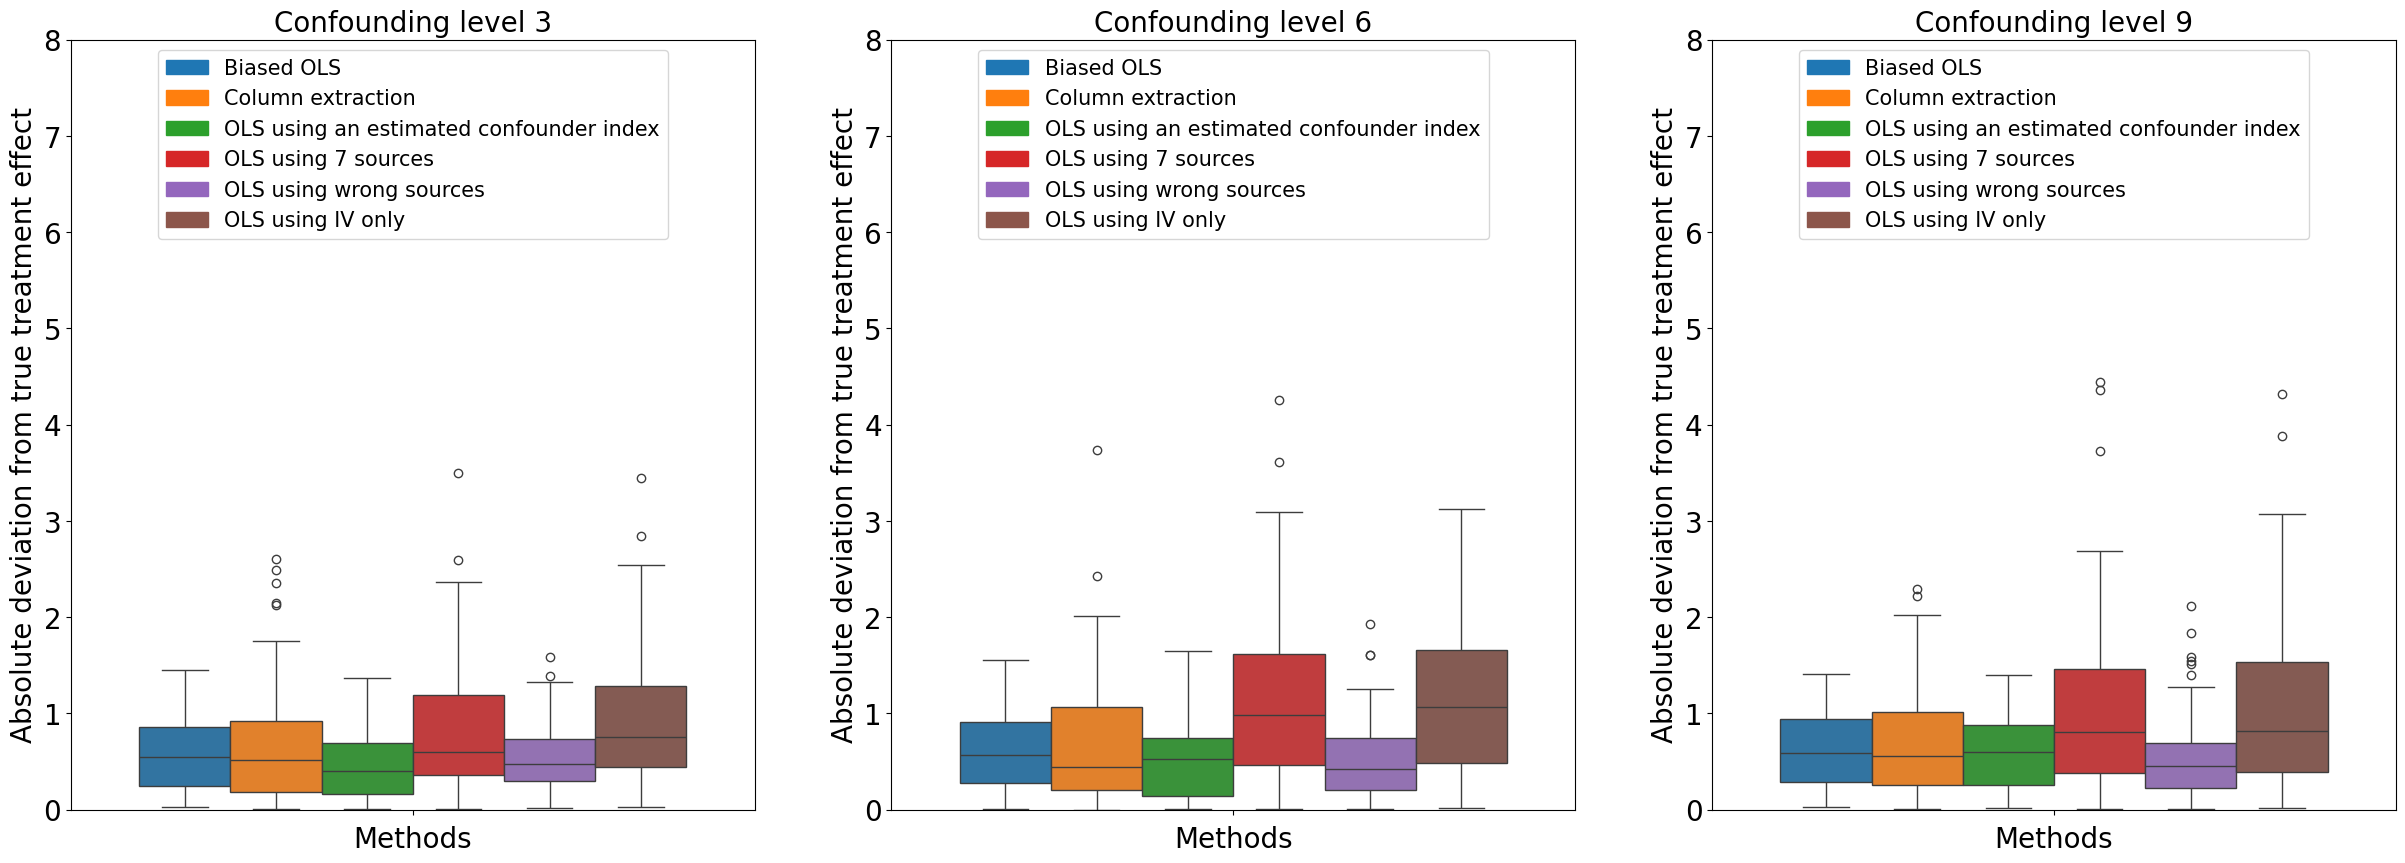

In [44]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(number_of_covariates), figsize=(30, 10))
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/different_numbers_of_covariates/data/", name  = f"estimated_mixing_CausalVarEM_covs_{covs}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], covs)
    
    plt.show()
    return method_summary

# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)




In [47]:
print_method_summary(method_summary)

Level 3
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.694980           0.899986                                 0.592682   
MAE      0.572190           0.680046                                 0.474014   
STD      0.692949           0.886726                                 0.588437   
Cases  100.000000         100.000000                                65.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.056558                 0.653320           1.177443  
MAE               0.829287                 0.542643           0.943052  
STD               1.033361                 0.650378           1.135129  
Cases            89.000000                86.000000          86.000000  
Level 6
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.641642   
MAE      0.585996           0.674720               

## Sample size


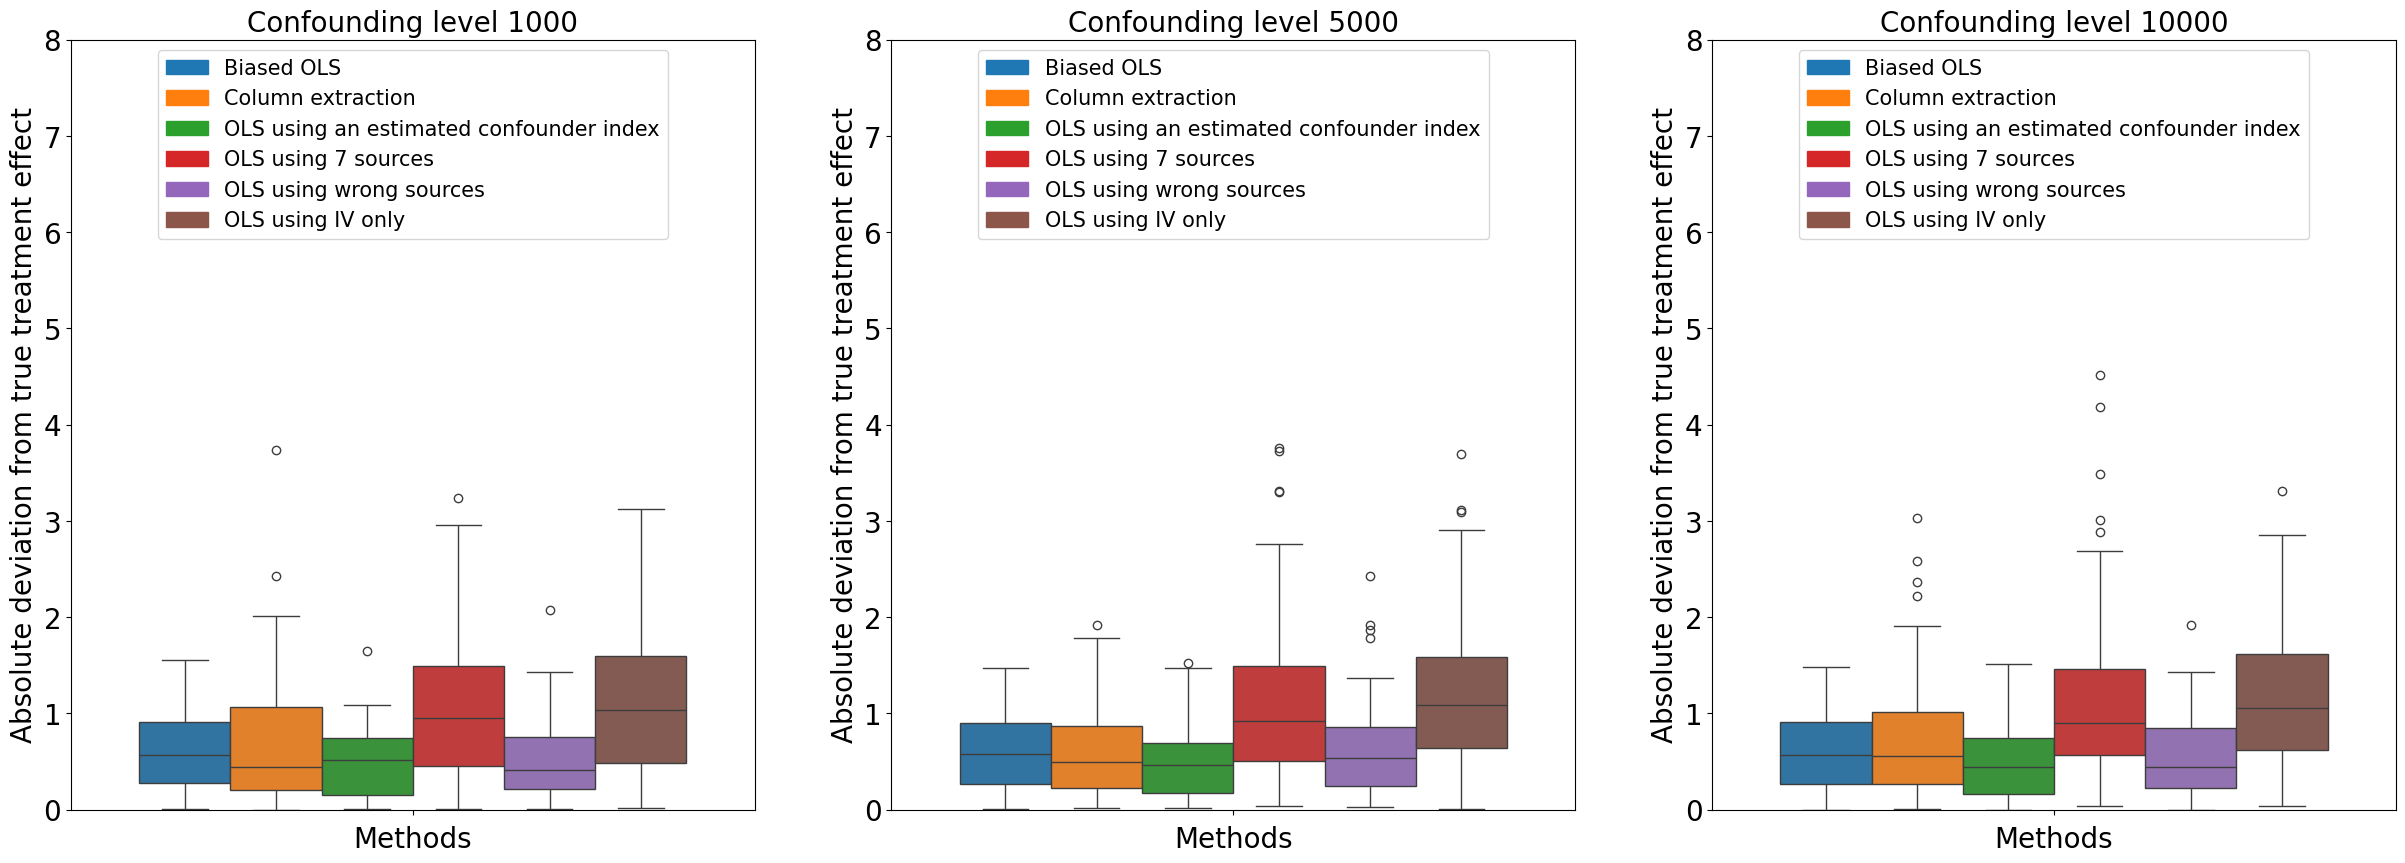

In [48]:
def main_plot(ns):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(ns), figsize=(30, 10))
    
    for i, n in enumerate(ns):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/differen_sample_sizes/data/", name=f"true_mixing_n:{n}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/differen_sample_sizes/data/", name=f"data_obs_n:{n}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)

        column_extraction_est = column_extraction(path = "data_generation/differen_sample_sizes/data/", name  = f"estimated_mixing_CausalVarEM_n:{n}")
        column_extraction_est = np.array(column_extraction_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(column_extraction_est)**2)), "MAE": np.mean(np.abs(column_extraction_est)), "STD": np.std(column_extraction_est)}, rmse, mae, std)

        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_n:{n}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_n:{n}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_n:{n}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_iv_only_n:{n}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        
        err = prepare_error_dataframe(ols_est, column_extraction_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[n] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], n)
    
    plt.show()
    return method_summary

# Example usage
ns = [1000, 5000, 10000]
method_summary = main_plot(ns)


In [49]:
print_method_summary(method_summary)

Level 1000
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.688614           0.922881                                 0.623532   
MAE      0.585996           0.674720                                 0.503053   
STD      0.687864           0.921088                                 0.619723   
Cases  100.000000         100.000000                                74.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.288739                 0.650628           1.347846  
MAE               1.052006                 0.517984           1.121672  
STD               1.275339                 0.627478           1.344736  
Cases            95.000000                81.000000          88.000000  
Level 5000
       Biased OLS  Column extraction  OLS using an estimated confounder index  \
RMSE     0.692705           0.758405                                 0.632016   
MAE      0.587399           0.602975         

# f score for different confounding levels

In [16]:
import itertools
import scipy as sp
from tqdm import tqdm
from metrics import *

In [17]:
fscores = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals_best_perm = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
confounder_levels = [1, 3, 6]
for cn in confounder_levels:
    for i in tqdm(range(100)):
        est_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_signals_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_signals_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        hat = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_mixing_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        scores_signals.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values)
        perm, score = f_score(true.values, hat.values)
        fscores.loc[i, f"cn{cn}"] = score
        scores_signals_best_perm.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values[:, perm])
fscores.mean()
scores_signals.mean()
scores_signals_best_perm.mean()


100%|██████████| 100/100 [00:15<00:00,  6.43it/s]


cn1     0.88789
cn3    0.962901
cn6    1.054137
dtype: object

Text(0.5, 1.0, 'MSE of signal estimation with best permutation')

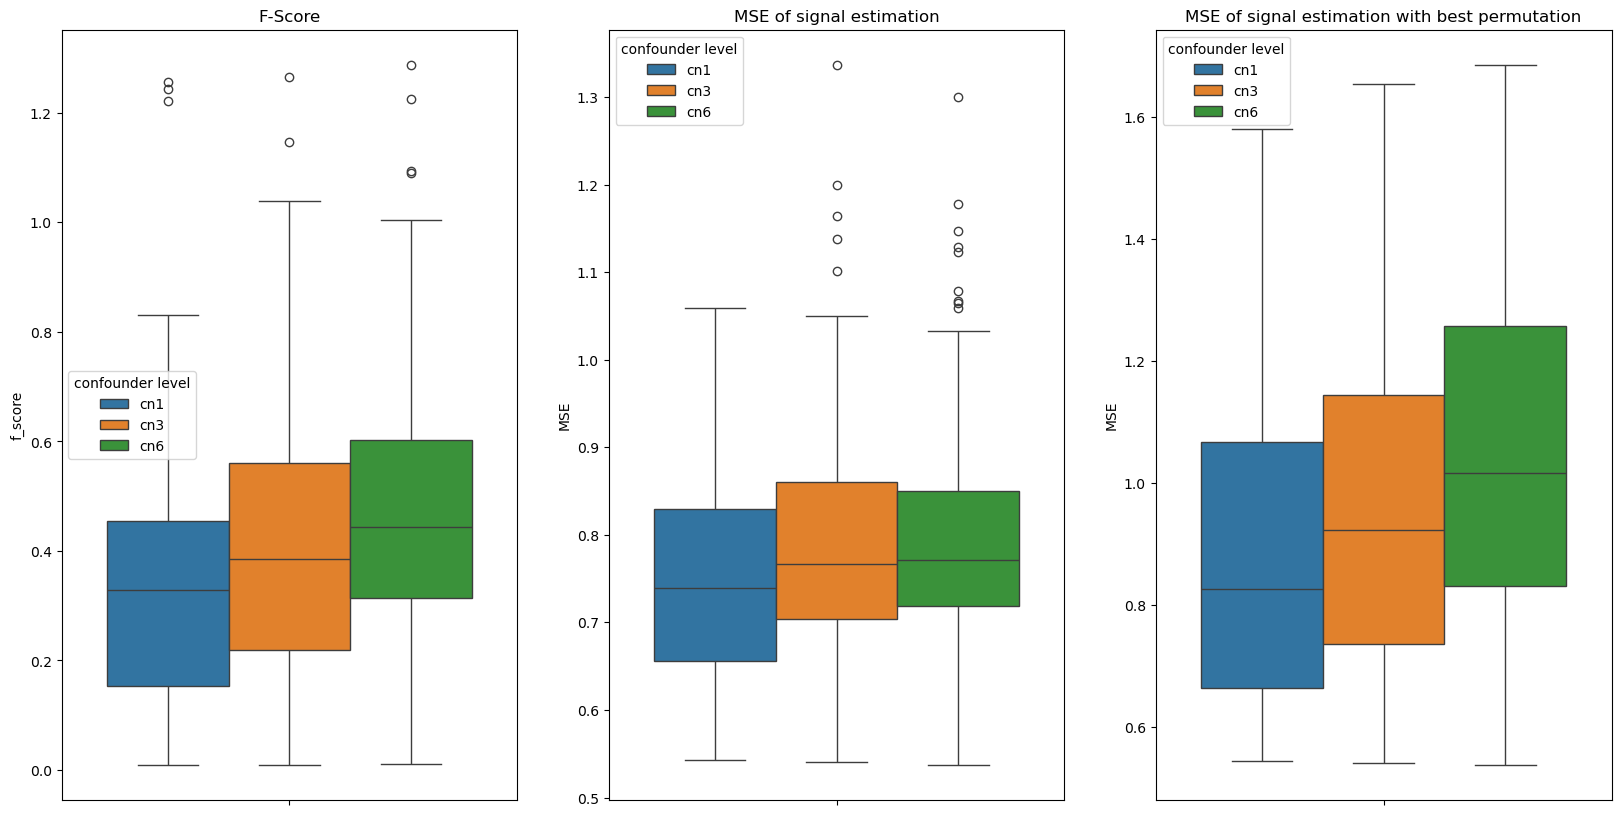

In [18]:
# plot the f_scores in one plot
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
long = fscores.melt(var_name="confounder level", value_name="f_score")
sns.boxplot(data=long, hue="confounder level", y="f_score", ax=ax[0])
ax[0].set_title("F-Score")

long = scores_signals.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[1])
ax[1].set_title("MSE of signal estimation")

long = scores_signals_best_perm.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[2])
ax[2].set_title("MSE of signal estimation with best permutation")



# plot error against level of confoundin

In [19]:
fscores

,cn1,cn3,cn6
0,0.036269,0.19288,0.462289
1,0.08107,0.290073,0.46752
2,0.471326,0.677667,0.828051
3,0.447514,0.523037,0.476763
4,0.17046,0.163433,0.151135
...,...,...,...
95,0.342981,0.416011,0.428562
96,0.062075,0.116893,0.312543
97,0.596928,0.597378,0.656245
98,0.829524,0.952856,1.089892


<Axes: xlabel='level_of_confounding', ylabel='cn6'>

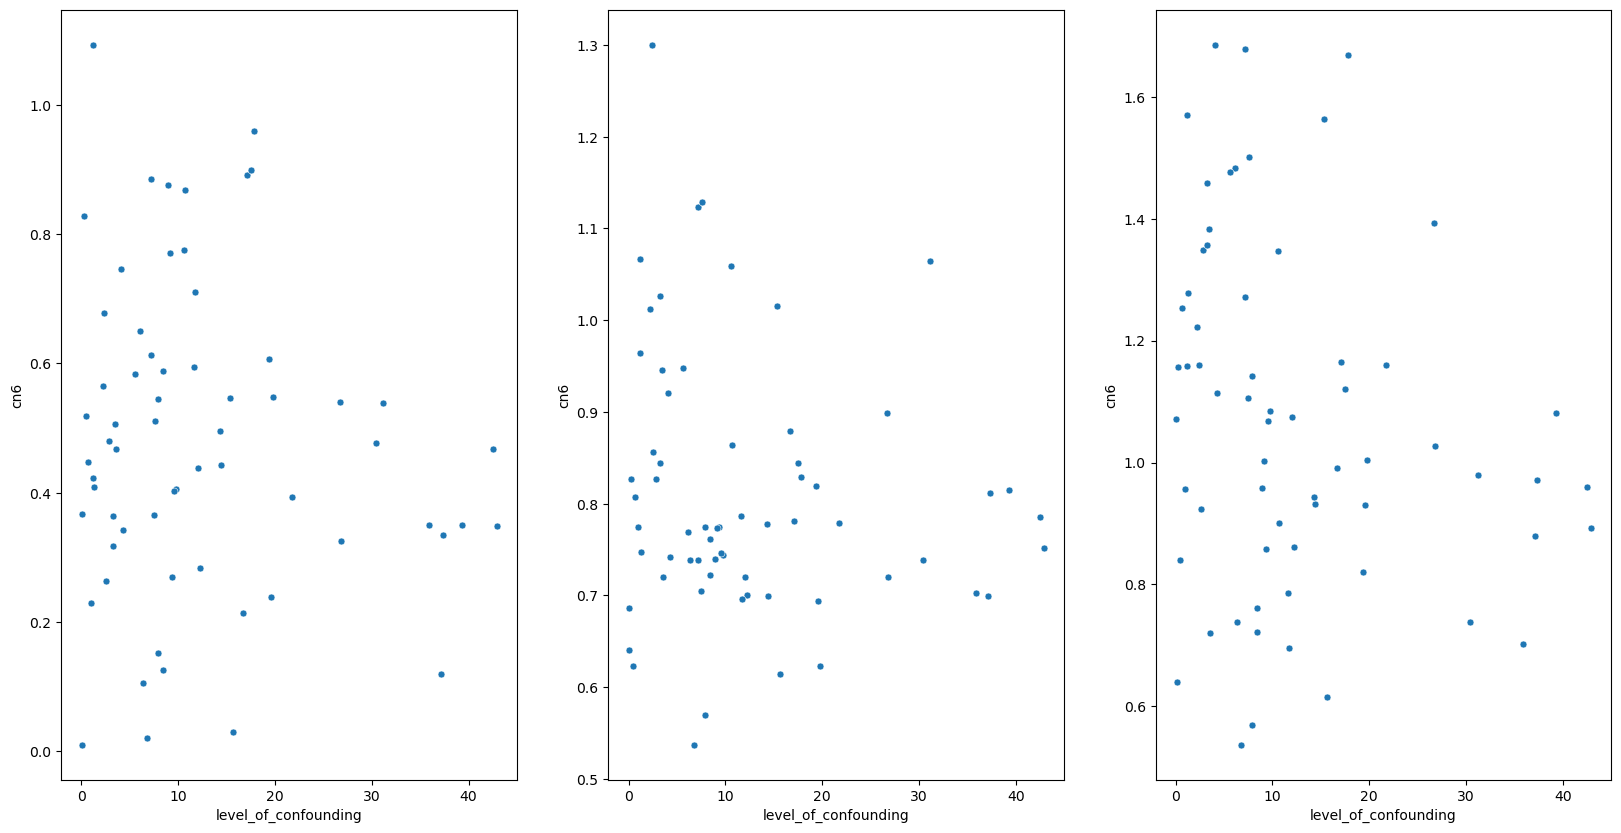

In [20]:
df1  = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header=0, index_col=0)
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
sns.scatterplot(data=df1, x="level_of_confounding", y=fscores["cn6"] ,s = 25, ax=ax[0])
sns.scatterplot(data=df1, x="level_of_confounding", y=scores_signals["cn6"] ,s = 25, ax=ax[1])
sns.scatterplot(data=df1, x="level_of_confounding", y=scores_signals_best_perm["cn6"] ,s = 25, ax=ax[2])


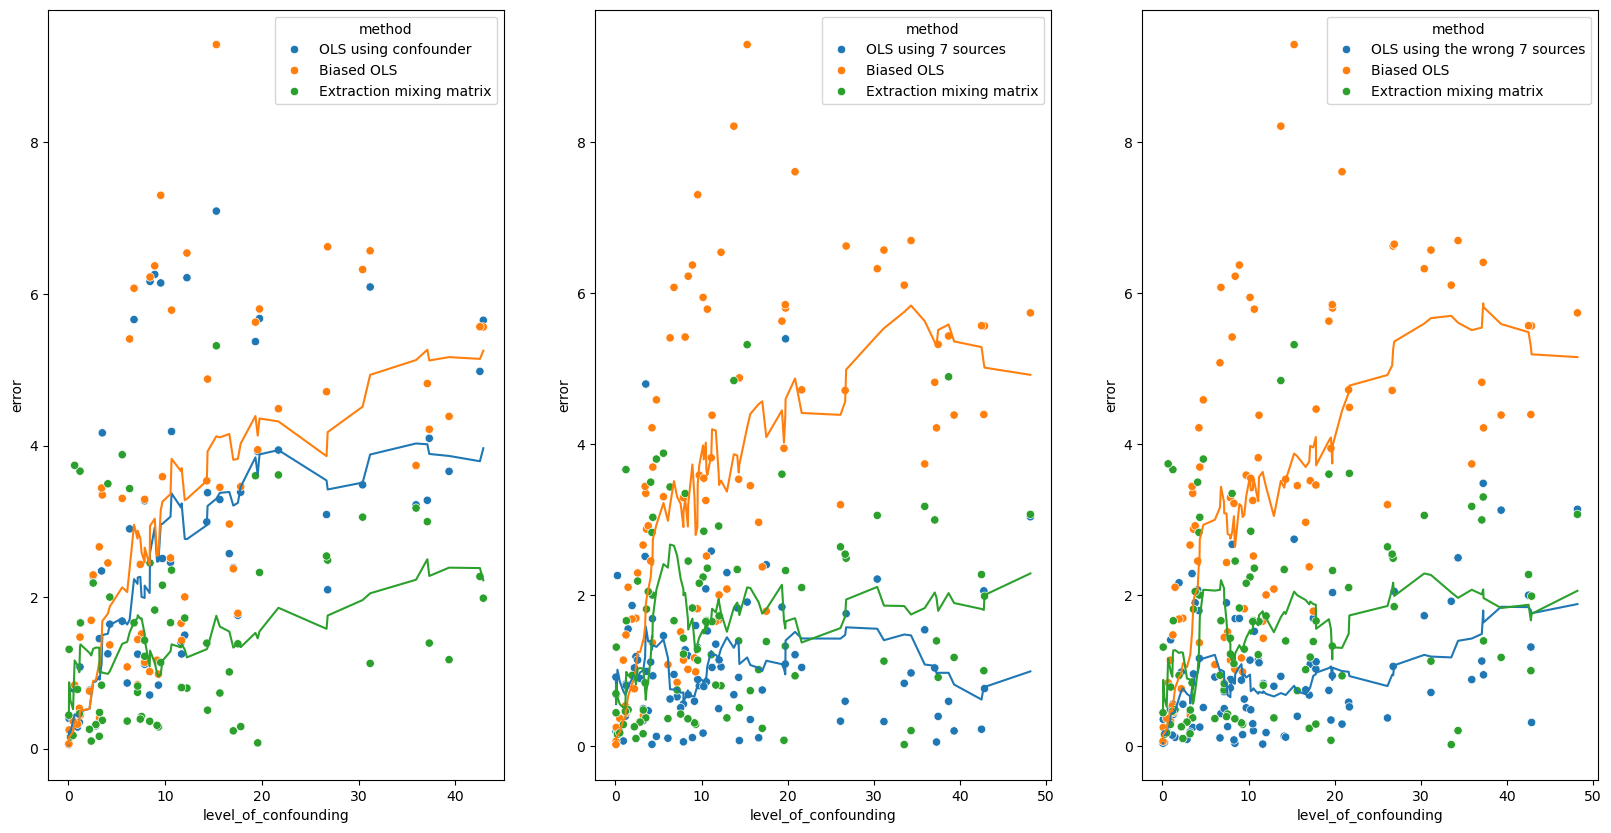

In [21]:

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax = plt.subplots(1, 3, figsize=(20, 10))

def rolling_average(data, x_col, y_col, hue_col, ax, window=10):
    unique_methods = data[hue_col].unique()
    for method in unique_methods:
        subset = data[data[hue_col] == method].sort_values(by=x_col)
        subset["smoothed_error"] = subset[y_col].rolling(window=window, min_periods=1).mean()
        ax.plot(subset[x_col], subset["smoothed_error"], label=f"Smoothed {method}")


df1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header=0, index_col=0)
x = df1["level_of_confounding"]
err1, seed = calc_error(df1)
err1 = err1.apply(lambda x: np.abs(x))
err1.columns = ["OLS using confounder", "Biased OLS" ,"Extraction mixing matrix"]
err1 = pd.concat([err1, x], axis=1)
err1 = err1.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err1, x="level_of_confounding", y="error", hue="method", ax=ax[0])
rolling_average(err1, "level_of_confounding", "error", "method", ax[0])

df2 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_6.csv", header=0, index_col=0)
x = df2["level_of_confounding"]
err2, seed = calc_error(df2)
err2 = err2.apply(lambda x: np.abs(x))
err2.columns = ["OLS using 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err2 = pd.concat([err2, x], axis=1)
err2 = err2.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err2, x="level_of_confounding", y="error", hue="method", ax=ax[1])
rolling_average(err2, "level_of_confounding", "error", "method", ax[1])

df3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_cn_6.csv", header=0, index_col=0)
x = df3["level_of_confounding"]
err3, seed = calc_error(df3)
err3 = err3.apply(lambda x: np.abs(x))
err3.columns = ["OLS using the wrong 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err3 = pd.concat([err3, x], axis=1)
err3 = err3.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err3, x="level_of_confounding", y="error", hue="method", ax=ax[2])
rolling_average(err3, "level_of_confounding", "error", "method", ax[2])

#plt.legend()
plt.show()


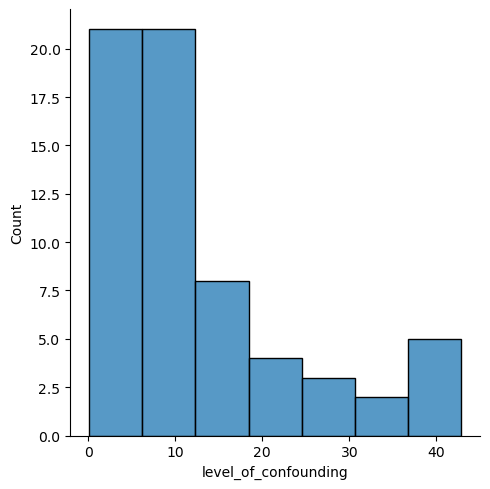

In [55]:
sns.displot(x = x)